# Notebook 04 — Prediction Simulations and Scenario Analysis (What-If)

**Level:** 4 (optional differentiator)  

**Depends on:** Notebooks 01, 02, and 03 must have been run.  



---



## ⚠️ Simulation Disclaimer



> **This notebook performs PREDICTIVE SIMULATIONS, not causal analysis.**  

> All scenario predictions are outputs of a machine learning model trained on

> historical data. The model has learned statistical associations between

> operational variables and % Silica Concentrate — it does NOT model the

> physical or chemical mechanisms of the flotation process.

>

> Scenario results should be interpreted as: *"If a similar historical pattern

> had occurred with this input combination, the model would have predicted X."*

> They are NOT engineering recommendations or process control instructions.

> Any operational change must be validated by process engineers and

> metallurgists before implementation.



---



## Objectives

1. Compare what-if behavior across multiple base cases from the unseen test set.

2. Quantify how the lagged-lab-availability model responds under operational,

   laboratory-trend, and combined scenario families.

3. Flag extrapolation risk whenever scenario inputs leave the historical

   training range.

4. Contrast the main lagged-lab model against the strict sensor-only fallback

   wherever both models can evaluate the same scenario family.

5. Save tables, charts, and optional MLflow artifacts for reproducible

   decision-support analysis.


In [2]:
import sys

from pathlib import Path



PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(0, str(PROJECT_ROOT))



import warnings

warnings.filterwarnings('ignore')



import json

import re

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



from src.config import CFG

from src.train import load_model, train_all_models, save_model, log_to_mlflow

from src.evaluate import compute_metrics

from src.predict import predict_single

from src.feature_engineering import run_feature_engineering_pipeline

from src.explain import align_feature_frame



sns.set_style('whitegrid')

plt.rcParams['figure.dpi'] = 120

FIGURES_PATH = Path(CFG['paths']['reports_figures'])

METRICS_PATH = Path(CFG['paths']['reports_metrics'])

MODELS_PATH = Path(CFG['paths']['models_selected'])

TARGET = CFG['target']


---

## 1. Load model and rebuild feature splits reproducibly



This notebook depends on notebook 02 for model artifacts and metadata, and on

the cleaned dataset produced by notebook 01. To make the flow reproducible from

zero, notebook 04 reconstructs train/validation/test features from

`data/interim/data_cleaned.parquet` with the same feature-engineering flags used

for the selected lagged-lab model, then validates strict schema consistency

against `models/selected/feature_columns.json`.


In [3]:
# Reproducible loading: models + metadata + reconstructed feature splits

FORCE_RETRAIN_LAB_DELAY_MODELS = False



primary_model_filename = 'model_lagged_lab_assumption.pkl'

fallback_model_filename = 'model_strict_no_lab_input.pkl'

selected_metadata_path = MODELS_PATH / 'selected_model_metadata.json'

feature_columns_path = MODELS_PATH / 'feature_columns.json'

interim_path = Path(CFG['paths']['data_interim']) / 'data_cleaned.parquet'



if not selected_metadata_path.exists():

    raise FileNotFoundError('Missing selected_model_metadata.json. Run notebook 02 first.')

if not feature_columns_path.exists():

    raise FileNotFoundError('Missing feature_columns.json. Run notebook 02 first.')

if not interim_path.exists():

    raise FileNotFoundError('Missing data/interim/data_cleaned.parquet. Run notebook 01 first.')



with open(selected_metadata_path, 'r', encoding='utf-8') as f:

    model_metadata = json.load(f)

with open(feature_columns_path, 'r', encoding='utf-8') as f:

    feature_columns = json.load(f)



primary_model_path = MODELS_PATH / primary_model_filename

if not primary_model_path.exists():

    raise FileNotFoundError(

        'Missing model_lagged_lab_assumption.pkl. Run notebook 02 first.'

    )



# Use the same load_model call style as notebook 03: folder + cfg + filename

model = load_model(folder='selected', cfg=CFG, filename=primary_model_filename)

strict_sensor_only_model = None

if (MODELS_PATH / fallback_model_filename).exists():

    strict_sensor_only_model = load_model(folder='selected', cfg=CFG, filename=fallback_model_filename)



repro_meta = model_metadata.get('reproducibility', {})

primary_meta = model_metadata.get('recommended_model_with_lagged_lab_assumption', {})



include_target_lags = bool(repro_meta.get('include_target_lags', primary_meta.get('uses_target_lags', True)))

include_feed_features = bool(repro_meta.get('include_feed_features', primary_meta.get('uses_feed_variables', True)))



df_clean = pd.read_parquet(interim_path)

X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = run_feature_engineering_pipeline(

    df_clean,

    cfg=CFG,

    save=False,

    include_target_lags=include_target_lags,

    include_feed_features=include_feed_features,

)



X_train = align_feature_frame(X_train_raw, feature_columns, dataset_name='X_train')

X_val = align_feature_frame(X_val_raw, feature_columns, dataset_name='X_val')

X_test = align_feature_frame(X_test_raw, feature_columns, dataset_name='X_test')



if list(X_test.columns) != feature_columns:

    raise ValueError(

        'X_test columns do not match feature_columns.json exactly in order and content. '

        'Re-run notebook 02 to regenerate consistent metadata/artifacts.'

    )



baseline_path = Path(CFG['paths']['reports_metrics']) / 'baseline_metrics.json'

if not baseline_path.exists():

    raise FileNotFoundError('Missing baseline_metrics.json. Run notebook 02 first.')

with open(baseline_path, 'r', encoding='utf-8') as f:

    baseline_metrics = json.load(f)



main_model_label = primary_meta.get('model_name', type(model).__name__)

fallback_model_label = model_metadata.get('strict_no_lab_input_fallback', {}).get(

    'model_name',

    type(strict_sensor_only_model).__name__ if strict_sensor_only_model is not None else 'Unavailable',

)



print(f'Main model: {type(model).__name__} | label={main_model_label}')

print(f'Strict sensor-only fallback loaded: {strict_sensor_only_model is not None} | label={fallback_model_label}')

print(f'Flags used to rebuild data: include_target_lags={include_target_lags}, include_feed_features={include_feed_features}')

print(f'Reconstructed train set: {X_train.shape}')

print(f'Reconstructed validation set: {X_val.shape}')

print(f'Reconstructed test set: {X_test.shape}')

print('Schema validation: X_test columns exactly match feature_columns.json')


[train] Model loaded from: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\model_lagged_lab_assumption.pkl
[train] Model loaded from: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\model_strict_no_lab_input.pkl
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
Main model: RandomForestRegressor | label=Random Forest
Strict sensor-only fallback loaded: True | label=Random Forest
Flags used to rebuild data: include_target_lags=True, include_feed_features=True
Reconstructed train set: (2855, 261)
Reconstructed validation set: (615, 261)
Reconstructed test set: (615, 261)
Schema validation: X_test columns exactly match feature_columns.json


---
## Lab delay availability scenarios

`% Silica Concentrate_lag_1` is especially influential in notebook 03. Because the modeling grain is hourly, `lag_1` represents approximately 1 hour before the inference timestamp.

This is only valid under an **availability assumption**: the latest laboratory result must already be available at inference time. It is not leakage if it corresponds to the last result already returned by the lab. It would be operational leakage only if that value were not yet available.

Scenarios below compare how predicted silica changes when progressively older laboratory information is the only lab history available.

- **`lag_1_available`**: allows `lag_1`, `lag_3`, `lag_6`, `lag_12`
- **`lag_3_available`**: excludes `lag_1`, allows `lag_3`, `lag_6`, `lag_12`
- **`lag_6_available`**: excludes `lag_1` and `lag_3`, allows `lag_6`, `lag_12`
- **`no_recent_lab_available`**: excludes all `% Silica Concentrate` lags; this is the strict sensor-only fallback

If performance drops sharply as recent lags are removed, the model relies heavily on persistence in the target rather than only on process sensors.

[lab-delay] Cache invalid for lag_1_available. Reason: Missing feature_columns in cache metadata. -> retraining.

[train] Fitting: Baseline (Mean)
[train] Baseline (Mean) | train: {'MAE': 0.9241, 'RMSE': np.float64(1.1265), 'R2': 0.0} | val: {'MAE': 0.7908, 'RMSE': np.float64(1.0331), 'R2': -0.0025}

[train] Fitting: Ridge
[train] Ridge | train: {'MAE': 0.4789, 'RMSE': np.float64(0.6802), 'R2': 0.6354} | val: {'MAE': 0.5383, 'RMSE': np.float64(0.7282), 'R2': 0.502}

[train] Fitting: Random Forest
[train] Random Forest | train: {'MAE': 0.3468, 'RMSE': np.float64(0.5103), 'R2': 0.7948} | val: {'MAE': 0.4856, 'RMSE': np.float64(0.6626), 'R2': 0.5876}

[train] Fitting: Extra Trees Regressor
[train] Extra Trees Regressor | train: {'MAE': 0.1963, 'RMSE': np.float64(0.3161), 'R2': 0.9213} | val: {'MAE': 0.4818, 'RMSE': np.float64(0.6629), 'R2': 0.5873}

[train] Fitting: XGBoost
[train] XGBoost | train: {'MAE': 0.0306, 'RMSE': np.float64(0.0405), 'R2': 0.9987} | val: {'MAE': 0.6427, 'RMSE': np

,Scenario,Availability assumption,Allowed lags,Best model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2,MAE improvement vs baseline (%),RMSE improvement vs baseline (%)
0,lag_1_available,The latest lab result from roughly 1 hour ago ...,"1, 3, 6, 12",Random Forest,0.4856,0.6626,0.5876,0.5500,0.7474,0.6096,44.53,37.77
1,lag_3_available,The latest lab result available is at least 3 ...,"3, 6, 12",Extra Trees Regressor,0.6552,0.8860,0.2626,0.7937,1.0027,0.2973,19.96,16.52
2,lag_6_available,Recent lab results are not available; only old...,"6, 12",Random Forest,0.8034,1.0064,0.0486,0.9084,1.1170,0.1281,8.39,7.00
3,no_recent_lab_available,No recent lab values are available; the model ...,none,Random Forest,0.7709,1.0006,0.0595,0.9306,1.1671,0.0480,6.15,2.83


Lagged-lab-availability model: lag_1_available | model=Random Forest | R²=0.6096
Strict sensor-only fallback: no_recent_lab_available | model=Random Forest | R²=0.048


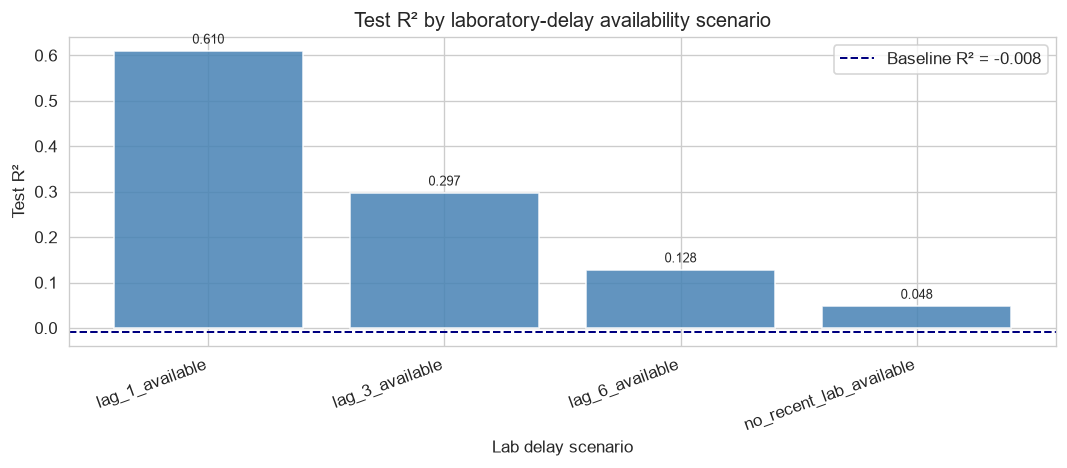

Lab-delay scenario table saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\lab_delay_availability_scenarios.csv
Lab-delay R² chart saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\lab_delay_availability_r2.png


In [4]:
# Lab-delay availability scenario evaluation (same temporal split as notebook 02)

baseline_test = baseline_metrics['Test']



target_lag_pattern = re.compile(rf"^{re.escape(TARGET)}_lag_(\d+)$")

target_lag_columns = [c for c in X_train.columns if target_lag_pattern.match(c)]



def subset_by_allowed_lags(X: pd.DataFrame, allowed_lags: list[int]) -> pd.DataFrame:

    keep_cols = []

    for col in X.columns:

        match = target_lag_pattern.match(col)

        if match:

            lag = int(match.group(1))

            if lag in allowed_lags:

                keep_cols.append(col)

        else:

            keep_cols.append(col)

    return X.loc[:, keep_cols].copy()



def cache_is_valid(sc_meta: dict, X_test_sc: pd.DataFrame) -> tuple[bool, str]:

    if not isinstance(sc_meta, dict):

        return False, 'Invalid metadata format.'

    if 'feature_columns' not in sc_meta:

        return False, 'Missing feature_columns in cache metadata.'

    cached_features = sc_meta.get('feature_columns')

    if not isinstance(cached_features, list):

        return False, 'feature_columns in metadata is not a list.'

    current_features = list(X_test_sc.columns)

    if cached_features != current_features:

        return False, 'Cached feature schema does not match current scenario features.'

    if len(cached_features) != X_test_sc.shape[1]:

        return False, 'Cached feature count does not match X_test scenario columns.'

    return True, ''



lab_delay_scenarios = [

    {

        'scenario': 'lag_1_available',

        'allowed_lags': [1, 3, 6, 12],

        'availability_assumption': 'The latest lab result from roughly 1 hour ago is available at inference time.',

    },

    {

        'scenario': 'lag_3_available',

        'allowed_lags': [3, 6, 12],

        'availability_assumption': 'The latest lab result available is at least 3 hours old.',

    },

    {

        'scenario': 'lag_6_available',

        'allowed_lags': [6, 12],

        'availability_assumption': 'Recent lab results are not available; only older lab history is accessible.',

    },

    {

        'scenario': 'no_recent_lab_available',

        'allowed_lags': [],

        'availability_assumption': 'No recent lab values are available; the model is strictly sensor-only.',

    },

]



lab_delay_results = {}

scenario_rows = []



for sc in lab_delay_scenarios:

    scenario_name = sc['scenario']

    cache_model_filename = f'{scenario_name}_best_model.pkl'

    cache_model_path = MODELS_PATH / cache_model_filename

    cache_meta_path = MODELS_PATH / f'{scenario_name}_best_model_metadata.json'



    X_train_sc = subset_by_allowed_lags(X_train, sc['allowed_lags'])

    X_val_sc = subset_by_allowed_lags(X_val, sc['allowed_lags'])

    X_test_sc = subset_by_allowed_lags(X_test, sc['allowed_lags'])



    use_cache = False

    sc_meta = {}

    if not FORCE_RETRAIN_LAB_DELAY_MODELS and cache_model_path.exists() and cache_meta_path.exists():

        with open(cache_meta_path, 'r', encoding='utf-8') as f:

            sc_meta = json.load(f)

        use_cache, cache_reason = cache_is_valid(sc_meta, X_test_sc)

        if not use_cache:

            print(f"[lab-delay] Cache invalid for {scenario_name}. Reason: {cache_reason} -> retraining.")

    elif FORCE_RETRAIN_LAB_DELAY_MODELS:

        cache_reason = 'FORCE_RETRAIN_LAB_DELAY_MODELS=True'

        print(f"[lab-delay] {scenario_name}: {cache_reason} -> retraining.")



    if use_cache:

        sc_model = load_model(folder='selected', cfg=CFG, filename=cache_model_filename)

        best_model_name = sc_meta['best_model_name']

        validation_metrics = sc_meta['validation_metrics']

        fitted_models = None

        all_metrics = None

    else:

        fitted_models, all_metrics = train_all_models(X_train_sc, y_train, X_val_sc, y_val, cfg=CFG)

        val_results_sc = {name: metrics['val'] for name, metrics in all_metrics.items()}

        val_table_sc = pd.DataFrame(val_results_sc).T.reset_index().rename(columns={'index': 'Model'})

        val_table_sc = val_table_sc.sort_values('RMSE').reset_index(drop=True)

        best_model_name = val_table_sc.iloc[0]['Model']

        sc_model = fitted_models[best_model_name]

        validation_metrics = all_metrics[best_model_name]['val']

        save_model(sc_model, model_name=best_model_name, folder='selected', cfg=CFG, filename=cache_model_filename)

        sc_meta = {

            'scenario': scenario_name,

            'allowed_lags': sc['allowed_lags'],

            'availability_assumption': sc['availability_assumption'],

            'best_model_name': best_model_name,

            'validation_metrics': validation_metrics,

            'feature_columns': list(X_train_sc.columns),

            'n_features': int(X_train_sc.shape[1]),

        }

        with open(cache_meta_path, 'w', encoding='utf-8') as f:

            json.dump(sc_meta, f, indent=2, ensure_ascii=False)



    y_pred_test_sc = sc_model.predict(X_test_sc)

    test_metrics = compute_metrics(y_test, y_pred_test_sc)



    scenario_rows.append({

        'Scenario': scenario_name,

        'Availability assumption': sc['availability_assumption'],

        'Allowed lags': ', '.join(map(str, sc['allowed_lags'])) if sc['allowed_lags'] else 'none',

        'Best model': best_model_name,

        'Validation MAE': validation_metrics['MAE'],

        'Validation RMSE': validation_metrics['RMSE'],

        'Validation R2': validation_metrics['R2'],

        'Test MAE': test_metrics['MAE'],

        'Test RMSE': test_metrics['RMSE'],

        'Test R2': test_metrics['R2'],

        'MAE improvement vs baseline (%)': round((baseline_test['MAE'] - test_metrics['MAE']) / baseline_test['MAE'] * 100, 2),

        'RMSE improvement vs baseline (%)': round((baseline_test['RMSE'] - test_metrics['RMSE']) / baseline_test['RMSE'] * 100, 2),

    })



    lab_delay_results[scenario_name] = {

        'model': sc_model,

        'best_model_name': best_model_name,

        'validation_metrics': validation_metrics,

        'test_metrics': test_metrics,

        'X_train': X_train_sc,

        'X_val': X_val_sc,

        'X_test': X_test_sc,

        'allowed_lags': sc['allowed_lags'],

        'cache_model_path': cache_model_path,

        'cache_meta_path': cache_meta_path,

    }



lab_delay_table = pd.DataFrame(scenario_rows)

lab_delay_csv_path = Path(CFG['paths']['reports_metrics']) / 'lab_delay_availability_scenarios.csv'

lab_delay_table.to_csv(lab_delay_csv_path, index=False)



principal_lagged_lab_scenario = 'lag_1_available'

strict_sensor_only_scenario = 'no_recent_lab_available'



model = lab_delay_results[principal_lagged_lab_scenario]['model']

strict_sensor_only_model = lab_delay_results[strict_sensor_only_scenario]['model']

X_train = lab_delay_results[principal_lagged_lab_scenario]['X_train']

X_val = lab_delay_results[principal_lagged_lab_scenario]['X_val']

X_test = lab_delay_results[principal_lagged_lab_scenario]['X_test']



print('\n=== Lab Delay Availability Scenarios ===')

display(lab_delay_table)



print(f'Lagged-lab-availability model: {principal_lagged_lab_scenario} | model={lab_delay_results[principal_lagged_lab_scenario]["best_model_name"]} | R²={lab_delay_results[principal_lagged_lab_scenario]["test_metrics"]["R2"]}')

print(f'Strict sensor-only fallback: {strict_sensor_only_scenario} | model={lab_delay_results[strict_sensor_only_scenario]["best_model_name"]} | R²={lab_delay_results[strict_sensor_only_scenario]["test_metrics"]["R2"]}')



fig, ax = plt.subplots(figsize=(9, 4))

order = ['lag_1_available', 'lag_3_available', 'lag_6_available', 'no_recent_lab_available']

plot_df = lab_delay_table.set_index('Scenario').loc[order].reset_index()

bars = ax.bar(plot_df['Scenario'], plot_df['Test R2'], color='steelblue', edgecolor='white', alpha=0.85)

ax.axhline(baseline_test['R2'], color='navy', linestyle='--', lw=1.2, label=f'Baseline R² = {baseline_test["R2"]:.3f}')

ax.set_title('Test R² by laboratory-delay availability scenario', fontsize=12)

ax.set_ylabel('Test R²')

ax.set_xlabel('Lab delay scenario')

ax.legend()

plt.xticks(rotation=20, ha='right')

for bar, val in zip(bars, plot_df['Test R2']):

    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()

lab_delay_r2_path = FIGURES_PATH / 'lab_delay_availability_r2.png'

plt.savefig(lab_delay_r2_path, dpi=150, bbox_inches='tight')

plt.show()



print(f'Lab-delay scenario table saved to: {lab_delay_csv_path}')

print(f'Lab-delay R² chart saved to: {lab_delay_r2_path}')


---

## 2. Select Multiple Base Cases from the Test Set



Instead of relying on a single reference observation, this notebook tracks four

base cases from the unseen test split:



- `median_quality_case`

- `high_silica_case`

- `low_silica_case`

- `high_error_case`



This makes the scenario analysis more defendible because the same scenario family

is evaluated under several historical operating contexts. The outputs remain

predictive summaries under the learned model behavior — not causal claims.


In [28]:
# Build a test-set case table and select four distinct base cases

y_pred_test = model.predict(X_test)

pred_series = pd.Series(y_pred_test, index=X_test.index, name='base_prediction')



case_pool = pd.DataFrame({

    'actual_value': y_test,

    'base_prediction': pred_series,

})

case_pool['absolute_error'] = (case_pool['actual_value'] - case_pool['base_prediction']).abs()

case_pool['predicted_silica_percentile'] = pred_series.rank(pct=True, method='average')

case_pool['timestamp'] = case_pool.index.astype(str)



selection_candidates = {

    'median_quality_case': case_pool['base_prediction'].sub(case_pool['base_prediction'].median()).abs().sort_values().index,

    'high_silica_case': case_pool['actual_value'].sort_values(ascending=False).index,

    'low_silica_case': case_pool['actual_value'].sort_values(ascending=True).index,

    'high_error_case': case_pool['absolute_error'].sort_values(ascending=False).index,

}



selected_indices = {}

used_indices = set()

for case_id, candidates in selection_candidates.items():

    for idx in candidates:

        if idx not in used_indices:

            selected_indices[case_id] = idx

            used_indices.add(idx)

            break



base_case_rows = {case_id: X_test.loc[[idx]].copy() for case_id, idx in selected_indices.items()}

base_case_rows_fallback = {}

if strict_sensor_only_model is not None:

    strict_X_test = lab_delay_results[strict_sensor_only_scenario]['X_test']

    base_case_rows_fallback = {

        case_id: strict_X_test.loc[[idx]].copy()

        for case_id, idx in selected_indices.items()

        if idx in strict_X_test.index

    }



base_case_records = []

for case_id, idx in selected_indices.items():

    base_case_records.append({

        'base_case_id': case_id,

        'index': str(idx),

        'timestamp': case_pool.loc[idx, 'timestamp'],

        'actual_value': round(float(case_pool.loc[idx, 'actual_value']), 4),

        'base_prediction': round(float(case_pool.loc[idx, 'base_prediction']), 4),

        'absolute_error': round(float(case_pool.loc[idx, 'absolute_error']), 4),

        'predicted_silica_percentile': round(float(case_pool.loc[idx, 'predicted_silica_percentile']), 4),

    })



base_cases_summary = pd.DataFrame(base_case_records)

base_cases_path = METRICS_PATH / 'base_cases_summary.csv'

base_cases_summary.to_csv(base_cases_path, index=False)



print('Selected base cases from the unseen test set:')

display(base_cases_summary)

print(f'Base-case summary saved to: {base_cases_path}')


Selected base cases from the unseen test set:


,base_case_id,index,timestamp,actual_value,base_prediction,absolute_error,predicted_silica_percentile
0,median_quality_case,2017-08-26 20:00:00,2017-08-26 20:00:00,2.31,2.1789,0.1311,0.5008
1,high_silica_case,2017-08-28 17:00:00,2017-08-28 17:00:00,5.53,2.3021,3.2279,0.5593
2,low_silica_case,2017-08-21 05:00:00,2017-08-21 05:00:00,0.84,1.6280,0.7880,0.1350
3,high_error_case,2017-08-18 06:00:00,2017-08-18 06:00:00,5.27,1.3440,3.9260,0.0358


Base-case summary saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\base_cases_summary.csv


---

## 3. Feature-Guided Scenario Design



Scenario construction combines three inputs:



1. **Manual operational scenarios** for Amina, Starch, and Ore Pulp pH.

2. **Top SHAP features** from notebook 03 to identify which important variables

   are operational levers, laboratory-trend features, calendar features, or

   non-actionable features.

3. **Sensitivity-guided combined packages** that follow the learned model

   behavior around the `median_quality_case` without implying causality.



Laboratory-trend scenarios are included only as *availability / recent-trend*

stress tests. They are **not operational levers**.


In [29]:
top_shap_path = METRICS_PATH / 'top_shap_features.csv'

if not top_shap_path.exists():

    raise FileNotFoundError('Missing reports/metrics/top_shap_features.csv. Run notebook 03 first.')



top_shap_features = pd.read_csv(top_shap_path)

fallback_feature_columns = (

    list(lab_delay_results[strict_sensor_only_scenario]['X_test'].columns)

    if strict_sensor_only_model is not None

    else []

)



def classify_feature(feature: str) -> str:

    if feature in {'hour', 'day', 'month', 'dayofweek', 'is_weekend'}:

        return 'time/calendar feature'

    if TARGET in feature and ('_lag_' in feature or 'roll_mean' in feature or 'rolling' in feature):

        return 'lab_trend_feature'

    operational_keywords = [

        'Amina Flow',

        'Starch Flow',

        'Ore Pulp pH',

        'Ore Pulp Flow',

        'Ore Pulp Density',

        'Flotation Column',

    ]

    if any(keyword in feature for keyword in operational_keywords) and not any(

        token in feature for token in ['_lag_', '_diff_', '_roll_']

    ):

        return 'operational_lever'

    return 'non_actionable feature'



top_shap_features['feature_type'] = top_shap_features['feature'].map(classify_feature)

top_shap_features['available_in_main_model'] = top_shap_features['feature'].isin(X_test.columns)

top_shap_features['available_in_fallback_model'] = top_shap_features['feature'].isin(fallback_feature_columns)



top_shap_feature_taxonomy = top_shap_features.copy()

taxonomy_path = METRICS_PATH / 'top_shap_feature_taxonomy.csv'

top_shap_feature_taxonomy.to_csv(taxonomy_path, index=False)



manual_feature_set = {'Amina Flow', 'Starch Flow', 'Ore Pulp pH'}

dynamic_operational_features = [

    feature

    for feature in top_shap_feature_taxonomy.loc[

        (top_shap_feature_taxonomy['feature_type'] == 'operational_lever')

        & (top_shap_feature_taxonomy['available_in_main_model']),

        'feature',

    ]

    if feature not in manual_feature_set

][:3]



lab_trend_feature_candidates = [

    feature

    for feature in top_shap_feature_taxonomy.loc[

        (top_shap_feature_taxonomy['feature_type'] == 'lab_trend_feature')

        & (top_shap_feature_taxonomy['available_in_main_model']),

        'feature',

    ]

]

lab_trend_feature_candidates = lab_trend_feature_candidates or [

    col for col in X_test.columns if TARGET in col and ('_lag_' in col or 'roll_mean' in col)

]

lab_trend_feature_candidates = list(dict.fromkeys(lab_trend_feature_candidates))[:3]



print('Top SHAP feature taxonomy:')

display(top_shap_feature_taxonomy)

print(f'Taxonomy saved to: {taxonomy_path}')

print(f'Dynamic operational features considered: {dynamic_operational_features}')

print(f'Laboratory-trend features considered: {lab_trend_feature_candidates}')


Top SHAP feature taxonomy:


,feature,mean_abs_shap,feature_type,available_in_main_model,available_in_fallback_model
0,% Silica Concentrate_lag_1,0.677142,lab_trend_feature,True,False
1,% Silica Concentrate_lag_3,0.038734,lab_trend_feature,True,False
2,month,0.013290,time/calendar feature,True,True
3,Flotation Column 07 Air Flow_roll_std_12,0.013069,non_actionable feature,True,True
4,Ore Pulp Flow_lag_12,0.011096,non_actionable feature,True,True
5,Ore Pulp pH_lag_1,0.008897,non_actionable feature,True,True
6,% Silica Feed_diff_1,0.008250,non_actionable feature,True,True
7,Flotation Column 02 Level,0.006699,operational_lever,True,True
8,Ore Pulp pH,0.005715,operational_lever,True,True
9,% Silica Concentrate_lag_12,0.005501,lab_trend_feature,True,False


Taxonomy saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\top_shap_feature_taxonomy.csv
Dynamic operational features considered: ['Flotation Column 02 Level']
Laboratory-trend features considered: ['% Silica Concentrate_lag_1', '% Silica Concentrate_lag_3', '% Silica Concentrate_lag_12']


---

## 4. Run Scenario Simulations Across All Base Cases



Each scenario is applied to every base case. Before scoring, the notebook checks

whether each modified value remains within the observed training range for the

main lagged-lab model. If a modification leaves the historical range, the row is

flagged with `Extrapolation risk`.


In [30]:
def scenario_step(feature: str, direction: int, scale: float = 1.0) -> dict:

    if feature == 'Ore Pulp pH':

        return {'mode': 'abs_delta', 'value': round(0.2 * scale * direction, 4)}

    return {'mode': 'pct', 'value': round(5.0 * scale * direction, 4)}



def apply_scenario_modifications(base_row: pd.DataFrame, modifications: dict) -> tuple[pd.DataFrame, list[dict]]:

    scenario_row = base_row.copy()

    applied = []

    for feature, spec in modifications.items():

        if feature not in scenario_row.columns:

            continue

        old_value = float(scenario_row[feature].iloc[0])

        if spec['mode'] == 'pct':

            new_value = old_value * (1 + spec['value'] / 100)

            change_label = f"{spec['value']:+.1f}%"

        elif spec['mode'] == 'abs_delta':

            new_value = old_value + spec['value']

            change_label = f"{spec['value']:+.3f}"

        elif spec['mode'] == 'set':

            new_value = float(spec['value'])

            change_label = f"set_to={new_value:.4f}"

        else:

            raise ValueError(f"Unsupported modification mode: {spec['mode']}")

        scenario_row[feature] = new_value

        applied.append({

            'feature': feature,

            'old_value': round(old_value, 4),

            'new_value': round(float(new_value), 4),

            'change': change_label,

            'mode': spec['mode'],

        })

    return scenario_row, applied



def validate_training_range(scenario_row: pd.DataFrame, modified_features: list[dict], training_frame: pd.DataFrame) -> tuple[bool, str]:

    violations = []

    for item in modified_features:

        feature = item['feature']

        if feature not in training_frame.columns:

            continue

        value = float(scenario_row[feature].iloc[0])

        lower = float(training_frame[feature].min())

        upper = float(training_frame[feature].max())

        if value < lower or value > upper:

            violations.append(

                f"{feature}: {value:.4f} outside [{lower:.4f}, {upper:.4f}]"

            )

    if violations:

        return False, 'Extrapolation risk | ' + '; '.join(violations)

    return True, ''



def build_interpretation(delta_prediction: float, scenario_type: str, scenario_name: str) -> str:

    if delta_prediction < 0:

        movement = f"the model predicts lower silica by {abs(delta_prediction):.4f}"

    elif delta_prediction > 0:

        movement = f"the model predicts higher silica by {abs(delta_prediction):.4f}"

    else:

        movement = 'the model predicts almost no change in silica'

    if scenario_type == 'lab_trend_feature':

        return (

            f"Under the learned model behavior, {scenario_name} is associated with a recent-lab-pattern stress test where {movement}. "

            "This is not a causal or operational recommendation."

        )

    return (

        f"Under the learned model behavior, {scenario_name} is associated with a scenario in which {movement}. "

        "This is not a causal or operational recommendation."

    )



median_case_row = base_case_rows['median_quality_case']

candidate_operational_features = []

for feature in ['Amina Flow', 'Starch Flow', 'Ore Pulp pH', *dynamic_operational_features]:

    if feature in median_case_row.columns and feature not in candidate_operational_features:

        candidate_operational_features.append(feature)



shap_strength = dict(zip(top_shap_feature_taxonomy['feature'], top_shap_feature_taxonomy['mean_abs_shap']))

sensitivity_rows = []

for feature in candidate_operational_features:

    scenario_up, _ = apply_scenario_modifications(median_case_row, {feature: scenario_step(feature, +1)})

    scenario_down, _ = apply_scenario_modifications(median_case_row, {feature: scenario_step(feature, -1)})

    pred_up = predict_single(model, scenario_up)

    pred_down = predict_single(model, scenario_down)

    if pred_up <= pred_down:

        lower_direction = +1

        higher_direction = -1

        best_lower_prediction = pred_up

        best_higher_prediction = pred_down

    else:

        lower_direction = -1

        higher_direction = +1

        best_lower_prediction = pred_down

        best_higher_prediction = pred_up

    sensitivity_rows.append({

        'feature': feature,

        'mean_abs_shap': shap_strength.get(feature, np.nan),

        'pred_if_negative_step': round(float(pred_down), 4),

        'pred_if_positive_step': round(float(pred_up), 4),

        'lower_direction': lower_direction,

        'higher_direction': higher_direction,

        'best_lower_prediction': round(float(best_lower_prediction), 4),

        'best_higher_prediction': round(float(best_higher_prediction), 4),

    })



sensitivity_evidence = pd.DataFrame(sensitivity_rows).sort_values(

    ['mean_abs_shap', 'feature'], ascending=[False, True]

).reset_index(drop=True)

sensitivity_evidence_path = METRICS_PATH / 'scenario_sensitivity_evidence.csv'

sensitivity_evidence.to_csv(sensitivity_evidence_path, index=False)



scenario_catalog = []



def register_scenario(name: str, scenario_type: str, modifications: dict, note: str) -> None:

    if modifications:

        scenario_catalog.append({

            'scenario_name': name,

            'scenario_type': scenario_type,

            'modifications': modifications,

            'note': note,

        })



if 'Amina Flow' in X_test.columns:

    register_scenario(

        'Amina Flow +5%',

        'manual_operational',

        {'Amina Flow': {'mode': 'pct', 'value': 5.0}},

        'Manual collector adjustment scenario for predictive stress testing.',

    )

    register_scenario(

        'Amina Flow -5%',

        'manual_operational',

        {'Amina Flow': {'mode': 'pct', 'value': -5.0}},

        'Manual collector adjustment scenario for predictive stress testing.',

    )

if 'Starch Flow' in X_test.columns:

    register_scenario(

        'Starch Flow -5%',

        'manual_operational',

        {'Starch Flow': {'mode': 'pct', 'value': -5.0}},

        'Manual depressant adjustment scenario for predictive stress testing.',

    )

    register_scenario(

        'Starch Flow +5%',

        'manual_operational',

        {'Starch Flow': {'mode': 'pct', 'value': 5.0}},

        'Manual depressant adjustment scenario for predictive stress testing.',

    )

if 'Ore Pulp pH' in X_test.columns:

    register_scenario(

        'Ore Pulp pH +0.2',

        'manual_operational',

        {'Ore Pulp pH': {'mode': 'abs_delta', 'value': 0.2}},

        'Manual pH adjustment scenario for predictive stress testing.',

    )

    register_scenario(

        'Ore Pulp pH -0.2',

        'manual_operational',

        {'Ore Pulp pH': {'mode': 'abs_delta', 'value': -0.2}},

        'Manual pH adjustment scenario for predictive stress testing.',

    )



for feature in dynamic_operational_features:

    register_scenario(

        f'{feature} +5%',

        'dynamic_operational',

        {feature: {'mode': 'pct', 'value': 5.0}},

        'Dynamic scenario based on top SHAP operational features that exist in the dataset.',

    )

    register_scenario(

        f'{feature} -5%',

        'dynamic_operational',

        {feature: {'mode': 'pct', 'value': -5.0}},

        'Dynamic scenario based on top SHAP operational features that exist in the dataset.',

    )



if lab_trend_feature_candidates:

    register_scenario(

        'recent lab silica trend +0.2 pp',

        'lab_trend_feature',

        {feature: {'mode': 'abs_delta', 'value': 0.2} for feature in lab_trend_feature_candidates},

        'Availability / recent-lab-trend scenario. These features are not operational levers.',

    )

    register_scenario(

        'recent lab silica trend -0.2 pp',

        'lab_trend_feature',

        {feature: {'mode': 'abs_delta', 'value': -0.2} for feature in lab_trend_feature_candidates},

        'Availability / recent-lab-trend scenario. These features are not operational levers.',

    )



top_package_features = sensitivity_evidence['feature'].tolist()[: min(3, len(sensitivity_evidence))]

if top_package_features:

    lower_package_mods = {}

    higher_package_mods = {}

    conservative_package_mods = {}

    process_drift_mods = {}

    for feature in top_package_features:

        lower_direction = int(sensitivity_evidence.loc[sensitivity_evidence['feature'] == feature, 'lower_direction'].iloc[0])

        lower_package_mods[feature] = scenario_step(feature, lower_direction, scale=1.0)

        higher_package_mods[feature] = scenario_step(feature, -lower_direction, scale=1.0)

        conservative_package_mods[feature] = scenario_step(feature, lower_direction, scale=0.5)

        process_drift_mods[feature] = scenario_step(feature, -lower_direction, scale=0.5)

    for feature in lab_trend_feature_candidates[:2]:

        process_drift_mods[feature] = {'mode': 'abs_delta', 'value': 0.2}



    register_scenario(

        'Lower predicted silica package',

        'combined_package',

        lower_package_mods,

        'Combined package aligned with lower-prediction directions inferred from local sensitivity around the median case.',

    )

    register_scenario(

        'Higher predicted silica stress test',

        'combined_package',

        higher_package_mods,

        'Combined stress test aligned with higher-prediction directions inferred from local sensitivity around the median case.',

    )

    register_scenario(

        'Conservative small-adjustment package',

        'combined_package',

        conservative_package_mods,

        'Smaller-magnitude package based on the same learned directions as the lower-prediction package.',

    )

    register_scenario(

        'Process drift warning scenario',

        'combined_package',

        process_drift_mods,

        'Pattern-based drift warning scenario using adverse local directions and recent-lab-trend stress where available.',

    )



scenario_catalog_df = pd.DataFrame([

    {

        'scenario_name': sc['scenario_name'],

        'scenario_type': sc['scenario_type'],

        'modified_features': ', '.join(sc['modifications'].keys()),

        'note': sc['note'],

    }

    for sc in scenario_catalog

])

scenario_parameters_path = METRICS_PATH / 'scenario_parameters.json'

with open(scenario_parameters_path, 'w', encoding='utf-8') as f:

    json.dump(scenario_catalog, f, indent=2, ensure_ascii=False)



scenario_rows = []

base_case_lookup = base_cases_summary.set_index('base_case_id')

for case_id, base_row in base_case_rows.items():

    base_prediction = float(base_case_lookup.loc[case_id, 'base_prediction'])

    actual_value = float(base_case_lookup.loc[case_id, 'actual_value'])

    absolute_error_base = float(base_case_lookup.loc[case_id, 'absolute_error'])

    for scenario in scenario_catalog:

        scenario_row, modified_features = apply_scenario_modifications(base_row, scenario['modifications'])

        if not modified_features:

            continue

        scenario_prediction = predict_single(model, scenario_row)

        delta_prediction = scenario_prediction - base_prediction

        delta_prediction_pct = (delta_prediction / base_prediction * 100) if base_prediction != 0 else np.nan

        within_training_range, range_warning = validate_training_range(

            scenario_row,

            modified_features,

            X_train,

        )

        scenario_rows.append({

            'base_case_id': case_id,

            'scenario_name': scenario['scenario_name'],

            'modified_features': json.dumps(modified_features, ensure_ascii=False),

            'base_prediction': round(base_prediction, 4),

            'scenario_prediction': round(float(scenario_prediction), 4),

            'delta_prediction': round(float(delta_prediction), 4),

            'delta_prediction_pct': round(float(delta_prediction_pct), 2) if not np.isnan(delta_prediction_pct) else np.nan,

            'actual_value': round(actual_value, 4),

            'absolute_error_base': round(absolute_error_base, 4),

            'scenario_type': scenario['scenario_type'],

            'interpretation': build_interpretation(float(delta_prediction), scenario['scenario_type'], scenario['scenario_name']),

            'within_training_range': within_training_range,

            'range_warning': range_warning,

        })



scenario_results = pd.DataFrame(scenario_rows)

scenario_results_path = METRICS_PATH / 'scenario_results.csv'

scenario_results.to_csv(scenario_results_path, index=False)



print('Scenario catalog:')

display(scenario_catalog_df)

print('\nScenario results sample:')

display(scenario_results.head(12))

print(f'Sensitivity evidence saved to: {sensitivity_evidence_path}')

print(f'Scenario parameters saved to: {scenario_parameters_path}')

print(f'Scenario results saved to: {scenario_results_path}')


Scenario catalog:


,scenario_name,scenario_type,modified_features,note
0,Amina Flow +5%,manual_operational,Amina Flow,Manual collector adjustment scenario for predi...
1,Amina Flow -5%,manual_operational,Amina Flow,Manual collector adjustment scenario for predi...
2,Starch Flow -5%,manual_operational,Starch Flow,Manual depressant adjustment scenario for pred...
3,Starch Flow +5%,manual_operational,Starch Flow,Manual depressant adjustment scenario for pred...
4,Ore Pulp pH +0.2,manual_operational,Ore Pulp pH,Manual pH adjustment scenario for predictive s...
5,Ore Pulp pH -0.2,manual_operational,Ore Pulp pH,Manual pH adjustment scenario for predictive s...
6,Flotation Column 02 Level +5%,dynamic_operational,Flotation Column 02 Level,Dynamic scenario based on top SHAP operational...
7,Flotation Column 02 Level -5%,dynamic_operational,Flotation Column 02 Level,Dynamic scenario based on top SHAP operational...
8,recent lab silica trend +0.2 pp,lab_trend_feature,"% Silica Concentrate_lag_1, % Silica Concentra...",Availability / recent-lab-trend scenario. Thes...
9,recent lab silica trend -0.2 pp,lab_trend_feature,"% Silica Concentrate_lag_1, % Silica Concentra...",Availability / recent-lab-trend scenario. Thes...



Scenario results sample:


,base_case_id,scenario_name,modified_features,base_prediction,scenario_prediction,delta_prediction,delta_prediction_pct,actual_value,absolute_error_base,scenario_type,interpretation,within_training_range,range_warning
0,median_quality_case,Amina Flow +5%,"[{""feature"": ""Amina Flow"", ""old_value"": 488.96...",2.1789,2.1785,-0.0004,-0.02,2.31,0.1311,manual_operational,"Under the learned model behavior, Amina Flow +...",True,
1,median_quality_case,Amina Flow -5%,"[{""feature"": ""Amina Flow"", ""old_value"": 488.96...",2.1789,2.1779,-0.0010,-0.05,2.31,0.1311,manual_operational,"Under the learned model behavior, Amina Flow -...",True,
2,median_quality_case,Starch Flow -5%,"[{""feature"": ""Starch Flow"", ""old_value"": 2990....",2.1789,2.1789,0.0000,0.00,2.31,0.1311,manual_operational,"Under the learned model behavior, Starch Flow ...",True,
3,median_quality_case,Starch Flow +5%,"[{""feature"": ""Starch Flow"", ""old_value"": 2990....",2.1789,2.1789,0.0000,0.00,2.31,0.1311,manual_operational,"Under the learned model behavior, Starch Flow ...",True,
4,median_quality_case,Ore Pulp pH +0.2,"[{""feature"": ""Ore Pulp pH"", ""old_value"": 8.889...",2.1789,2.1789,0.0000,0.00,2.31,0.1311,manual_operational,"Under the learned model behavior, Ore Pulp pH ...",True,
5,median_quality_case,Ore Pulp pH -0.2,"[{""feature"": ""Ore Pulp pH"", ""old_value"": 8.889...",2.1789,2.1789,0.0000,0.00,2.31,0.1311,manual_operational,"Under the learned model behavior, Ore Pulp pH ...",False,Extrapolation risk | Ore Pulp pH: 8.6896 outsi...
6,median_quality_case,Flotation Column 02 Level +5%,"[{""feature"": ""Flotation Column 02 Level"", ""old...",2.1789,2.1789,0.0000,0.00,2.31,0.1311,dynamic_operational,"Under the learned model behavior, Flotation Co...",True,
7,median_quality_case,Flotation Column 02 Level -5%,"[{""feature"": ""Flotation Column 02 Level"", ""old...",2.1789,2.1789,0.0000,0.00,2.31,0.1311,dynamic_operational,"Under the learned model behavior, Flotation Co...",True,
8,median_quality_case,recent lab silica trend +0.2 pp,"[{""feature"": ""% Silica Concentrate_lag_1"", ""ol...",2.1789,2.2556,0.0767,3.52,2.31,0.1311,lab_trend_feature,"Under the learned model behavior, recent lab s...",True,
9,median_quality_case,recent lab silica trend -0.2 pp,"[{""feature"": ""% Silica Concentrate_lag_1"", ""ol...",2.1789,1.9991,-0.1798,-8.25,2.31,0.1311,lab_trend_feature,"Under the learned model behavior, recent lab s...",True,


Sensitivity evidence saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\scenario_sensitivity_evidence.csv
Scenario parameters saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\scenario_parameters.json
Scenario results saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\scenario_results.csv


In [36]:
main_vs_fallback_path = None

main_vs_fallback_simulation = pd.DataFrame()



if strict_sensor_only_model is not None and base_case_rows_fallback:

    comparison_scenarios = [

        sc for sc in scenario_catalog if sc['scenario_type'] != 'lab_trend_feature'

    ]

    comparison_rows = []

    strict_X_train = lab_delay_results[strict_sensor_only_scenario]['X_train']

    for case_id, main_base_row in base_case_rows.items():

        if case_id not in base_case_rows_fallback:

            continue

        fallback_base_row = base_case_rows_fallback[case_id]

        main_base_prediction = predict_single(model, main_base_row)

        fallback_base_prediction = predict_single(strict_sensor_only_model, fallback_base_row)

        for scenario in comparison_scenarios:

            main_row, main_modifications = apply_scenario_modifications(main_base_row, scenario['modifications'])

            fallback_row, fallback_modifications = apply_scenario_modifications(fallback_base_row, scenario['modifications'])

            if not main_modifications or not fallback_modifications:

                continue

            main_scenario_prediction = predict_single(model, main_row)

            fallback_scenario_prediction = predict_single(strict_sensor_only_model, fallback_row)

            main_delta = float(main_scenario_prediction - main_base_prediction)

            fallback_delta = float(fallback_scenario_prediction - fallback_base_prediction)

            same_direction = np.sign(main_delta) == np.sign(fallback_delta) or (main_delta == 0 and fallback_delta == 0)

            fallback_less_sensitive = abs(fallback_delta) < abs(main_delta)

            if same_direction and fallback_less_sensitive:

                comparison_interpretation = (

                    'Both models agree on the direction; the fallback is less sensitive, so confidence is stronger for direction than magnitude.'

                )

            elif same_direction:

                comparison_interpretation = (

                    'Both models agree on direction and show comparable sensitivity under the learned model behavior.'

                )

            else:

                comparison_interpretation = (

                    'The models disagree on direction, so this scenario should be treated as low-confidence decision support.'

                )

            comparison_rows.append({

                'base_case_id': case_id,

                'scenario_name': scenario['scenario_name'],

                'scenario_type': scenario['scenario_type'],

                'main_delta_prediction': round(main_delta, 4),

                'fallback_delta_prediction': round(fallback_delta, 4),

                'direction_agreement': same_direction,

                'fallback_less_sensitive': fallback_less_sensitive,

                'main_within_training_range': validate_training_range(main_row, main_modifications, X_train)[0],

                'fallback_within_training_range': validate_training_range(fallback_row, fallback_modifications, strict_X_train)[0],

                'interpretation': comparison_interpretation,

            })

    main_vs_fallback_simulation = pd.DataFrame(comparison_rows)

    if not main_vs_fallback_simulation.empty:

        main_vs_fallback_simulation['scenario_risk_tag'] = np.where(

            main_vs_fallback_simulation['direction_agreement'],

            'directionally_consistent',

            'direction_disagreement_exploratory_only',

        )

        main_vs_fallback_simulation['recommended_use'] = np.where(

            main_vs_fallback_simulation['direction_agreement'],

            'decision_support_with_caution',

            'exploratory_not_operational_recommendation',

        )

    main_vs_fallback_path = METRICS_PATH / 'main_vs_fallback_simulation.csv'

    main_vs_fallback_simulation.to_csv(main_vs_fallback_path, index=False)



scenario_summary = (

    scenario_results.groupby(['scenario_name', 'scenario_type'], as_index=False)

    .agg(

        mean_delta_prediction=('delta_prediction', 'mean'),

        median_delta_prediction=('delta_prediction', 'median'),

        std_delta_prediction=('delta_prediction', 'std'),

        min_delta_prediction=('delta_prediction', 'min'),

        max_delta_prediction=('delta_prediction', 'max'),

        extrapolation_cases=('within_training_range', lambda s: int((~s).sum())),

        extrapolation_share=('within_training_range', lambda s: round(float((~s).mean()), 4)),

    )

)

scenario_summary['std_delta_prediction'] = scenario_summary['std_delta_prediction'].fillna(0.0)

direction_map = scenario_results.groupby('scenario_name')['delta_prediction'].apply(

    lambda s: len({int(np.sign(v)) for v in s if v != 0}) <= 1

)

scenario_summary['consistent_direction_across_cases'] = scenario_summary['scenario_name'].map(direction_map)



if not main_vs_fallback_simulation.empty:

    agreement_by_scenario = (

        main_vs_fallback_simulation.groupby('scenario_name')['direction_agreement']

        .mean()

        .rename('main_vs_fallback_agreement_rate')

    )

    scenario_summary = scenario_summary.merge(

        agreement_by_scenario,

        on='scenario_name',

        how='left',

    )

else:

    scenario_summary['main_vs_fallback_agreement_rate'] = np.nan



scenario_summary['main_interpretation_reliability'] = np.where(

    scenario_summary['scenario_type'].eq('lab_trend_feature'),

    'high_model_dependence_lag_availability',

    np.where(

        scenario_summary['main_vs_fallback_agreement_rate'].notna() & (scenario_summary['main_vs_fallback_agreement_rate'] < 0.5),

        'low_cross_model_agreement_exploratory',

        np.where(

            scenario_summary['extrapolation_cases'] > 0,

            'extrapolation_risk_caution',

            'directionally_stable_decision_support',

        ),

    ),

)



scenario_summary['recommended_use'] = np.where(

    scenario_summary['main_interpretation_reliability'].isin([

        'high_model_dependence_lag_availability',

        'low_cross_model_agreement_exploratory',

    ]),

    'exploratory_not_operational_recommendation',

    'decision_support_with_caution',

)



largest_reductions = scenario_summary.nsmallest(5, 'mean_delta_prediction').copy()

largest_reductions['ranking_bucket'] = 'largest_reduction'

largest_reductions['rank'] = range(1, len(largest_reductions) + 1)



largest_increases = scenario_summary.nlargest(5, 'mean_delta_prediction').copy()

largest_increases['ranking_bucket'] = 'largest_increase'

largest_increases['rank'] = range(1, len(largest_increases) + 1)



largest_extrapolation_risk = scenario_summary.sort_values(

    ['extrapolation_cases', 'extrapolation_share', 'std_delta_prediction'],

    ascending=[False, False, False],

).head(5).copy()

largest_extrapolation_risk['ranking_bucket'] = 'largest_extrapolation_risk'

largest_extrapolation_risk['rank'] = range(1, len(largest_extrapolation_risk) + 1)



scenario_ranking = pd.concat(

    [largest_reductions, largest_increases, largest_extrapolation_risk],

    ignore_index=True,

)

scenario_ranking_path = METRICS_PATH / 'scenario_ranking.csv'

scenario_ranking.to_csv(scenario_ranking_path, index=False)



executive_hallazgo_table = pd.DataFrame([

    {

        'finding': 'Largest prediction shifts come from recent-lab-trend scenarios',

        'evidence': scenario_summary.loc[

            scenario_summary['scenario_type'] == 'lab_trend_feature',

            ['scenario_name', 'mean_delta_prediction']

        ].sort_values('mean_delta_prediction', key=lambda s: s.abs(), ascending=False).head(2).to_dict('records'),

        'implication': 'Treat as availability/trend stress tests, not direct operational levers.',

        'recommended_use': 'exploratory_not_operational_recommendation',

    },

    {

        'finding': 'Cross-model directional agreement is limited when lab lags are removed',

        'evidence': (

            round(float(main_vs_fallback_simulation['direction_agreement'].mean()), 4)

            if not main_vs_fallback_simulation.empty else np.nan

        ),

        'implication': 'Scenario interpretation is model-assumption dependent under strict no-lag constraints.',

        'recommended_use': 'decision_support_with_high_caution',

    },

])

executive_hallazgo_path = METRICS_PATH / 'executive_hallazgo_summary.csv'

executive_hallazgo_table.to_csv(executive_hallazgo_path, index=False)



print('Scenario summary:')

display(scenario_summary.sort_values('mean_delta_prediction'))

print('\nExecutive hallazgo table:')

display(executive_hallazgo_table)

if main_vs_fallback_path is not None:

    print('\nMain vs fallback comparison sample:')

    display(main_vs_fallback_simulation.head(12))

    print(f'Main-vs-fallback table saved to: {main_vs_fallback_path}')

else:

    print('\nMain-vs-fallback comparison skipped because the strict sensor-only model is unavailable.')

print(f'Scenario ranking saved to: {scenario_ranking_path}')

print(f'Executive hallazgo summary saved to: {executive_hallazgo_path}')


Scenario summary:


,scenario_name,scenario_type,mean_delta_prediction,median_delta_prediction,std_delta_prediction,min_delta_prediction,max_delta_prediction,extrapolation_cases,extrapolation_share,consistent_direction_across_cases,main_vs_fallback_agreement_rate,main_interpretation_reliability,recommended_use
13,recent lab silica trend -0.2 pp,lab_trend_feature,-0.160375,-0.11325,0.167176,-0.3893,-0.0257,0,0.00,True,NaN,high_model_dependence_lag_availability,exploratory_not_operational_recommendation
11,Starch Flow -5%,manual_operational,-0.000275,0.00000,0.000550,-0.0011,0.0000,0,0.00,True,0.50,directionally_stable_decision_support,decision_support_with_caution
1,Amina Flow -5%,manual_operational,-0.000250,0.00000,0.000500,-0.0010,-0.0000,0,0.00,True,0.50,directionally_stable_decision_support,decision_support_with_caution
5,Higher predicted silica stress test,combined_package,-0.000125,-0.00005,0.000189,-0.0004,-0.0000,1,0.25,True,0.25,low_cross_model_agreement_exploratory,exploratory_not_operational_recommendation
0,Amina Flow +5%,manual_operational,-0.000100,0.00000,0.000200,-0.0004,-0.0000,0,0.00,True,0.25,low_cross_model_agreement_exploratory,exploratory_not_operational_recommendation
3,Flotation Column 02 Level +5%,dynamic_operational,-0.000025,-0.00000,0.000050,-0.0001,0.0000,0,0.00,True,0.75,directionally_stable_decision_support,decision_support_with_caution
4,Flotation Column 02 Level -5%,dynamic_operational,0.000000,0.00000,0.000000,0.0000,0.0000,0,0.00,True,0.50,directionally_stable_decision_support,decision_support_with_caution
10,Starch Flow +5%,manual_operational,0.000000,0.00000,0.000000,0.0000,0.0000,0,0.00,True,0.25,low_cross_model_agreement_exploratory,exploratory_not_operational_recommendation
8,Ore Pulp pH -0.2,manual_operational,0.000000,0.00000,0.000000,0.0000,0.0000,1,0.25,True,0.25,low_cross_model_agreement_exploratory,exploratory_not_operational_recommendation
2,Conservative small-adjustment package,combined_package,0.000525,-0.00000,0.001780,-0.0010,0.0031,0,0.00,False,0.75,directionally_stable_decision_support,decision_support_with_caution



Executive hallazgo table:


,finding,evidence,implication,recommended_use
0,Largest prediction shifts come from recent-lab...,[{'scenario_name': 'recent lab silica trend -0...,"Treat as availability/trend stress tests, not ...",exploratory_not_operational_recommendation
1,Cross-model directional agreement is limited w...,0.4375,Scenario interpretation is model-assumption de...,decision_support_with_high_caution



Main vs fallback comparison sample:


,base_case_id,scenario_name,scenario_type,main_delta_prediction,fallback_delta_prediction,direction_agreement,fallback_less_sensitive,main_within_training_range,fallback_within_training_range,interpretation,scenario_risk_tag,recommended_use
0,median_quality_case,Amina Flow +5%,manual_operational,-0.0005,0.3062,False,False,True,True,"The models disagree on direction, so this scen...",direction_disagreement_exploratory_only,exploratory_not_operational_recommendation
1,median_quality_case,Amina Flow -5%,manual_operational,-0.0010,-0.0642,True,False,True,True,Both models agree on direction and show compar...,directionally_consistent,decision_support_with_caution
2,median_quality_case,Starch Flow -5%,manual_operational,-0.0000,-0.0000,True,False,True,True,Both models agree on direction and show compar...,directionally_consistent,decision_support_with_caution
3,median_quality_case,Starch Flow +5%,manual_operational,0.0000,0.0000,False,False,True,True,"The models disagree on direction, so this scen...",direction_disagreement_exploratory_only,exploratory_not_operational_recommendation
4,median_quality_case,Ore Pulp pH +0.2,manual_operational,-0.0000,-0.0000,True,True,True,True,Both models agree on the direction; the fallba...,directionally_consistent,decision_support_with_caution
5,median_quality_case,Ore Pulp pH -0.2,manual_operational,-0.0000,-0.0000,True,False,False,False,Both models agree on direction and show compar...,directionally_consistent,decision_support_with_caution
6,median_quality_case,Flotation Column 02 Level +5%,dynamic_operational,-0.0000,-0.0030,True,False,True,True,Both models agree on direction and show compar...,directionally_consistent,decision_support_with_caution
7,median_quality_case,Flotation Column 02 Level -5%,dynamic_operational,0.0000,0.0017,False,False,True,True,"The models disagree on direction, so this scen...",direction_disagreement_exploratory_only,exploratory_not_operational_recommendation
8,median_quality_case,Lower predicted silica package,combined_package,-0.0010,-0.0624,True,False,True,True,Both models agree on direction and show compar...,directionally_consistent,decision_support_with_caution
9,median_quality_case,Higher predicted silica stress test,combined_package,-0.0005,0.3010,False,False,False,False,"The models disagree on direction, so this scen...",direction_disagreement_exploratory_only,exploratory_not_operational_recommendation


Main-vs-fallback table saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\main_vs_fallback_simulation.csv
Scenario ranking saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\scenario_ranking.csv
Executive hallazgo summary saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\executive_hallazgo_summary.csv


---

## 5. Visualisations



The plots below summarise scenario direction, magnitude, case-to-case robustness,

and agreement between the main lagged-lab model and the strict sensor-only

fallback. They should be read as predictive pattern summaries under the learned

model behavior.


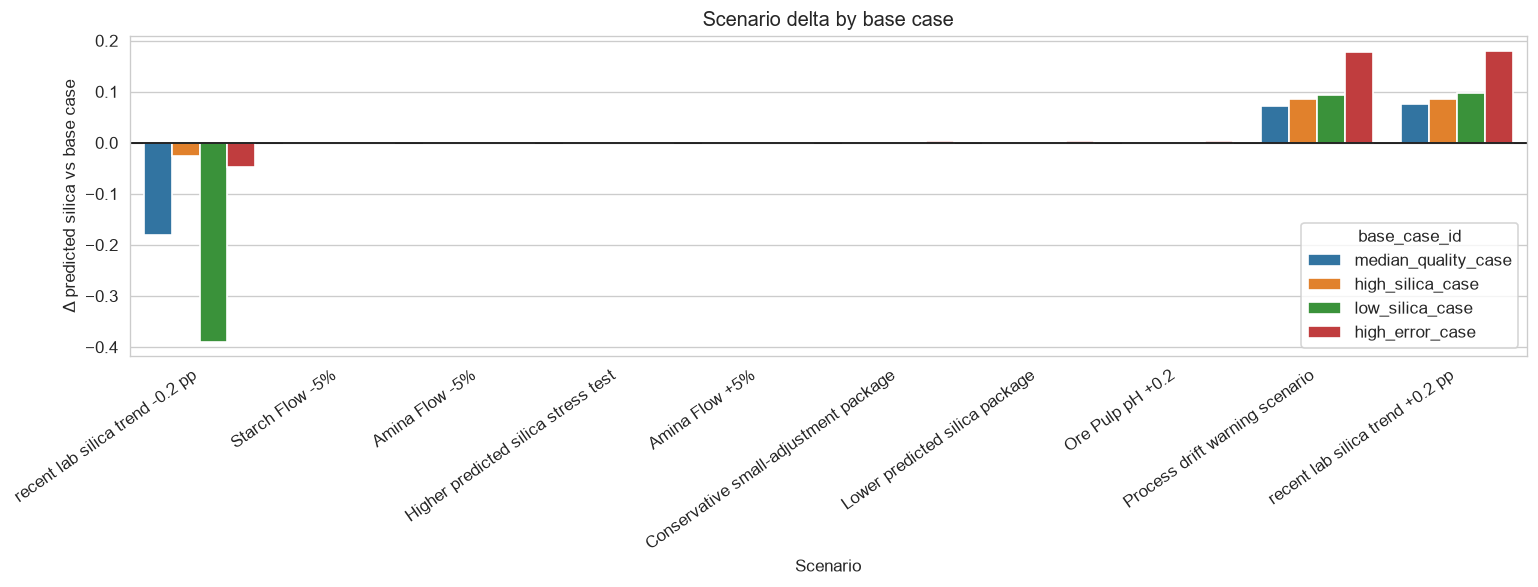

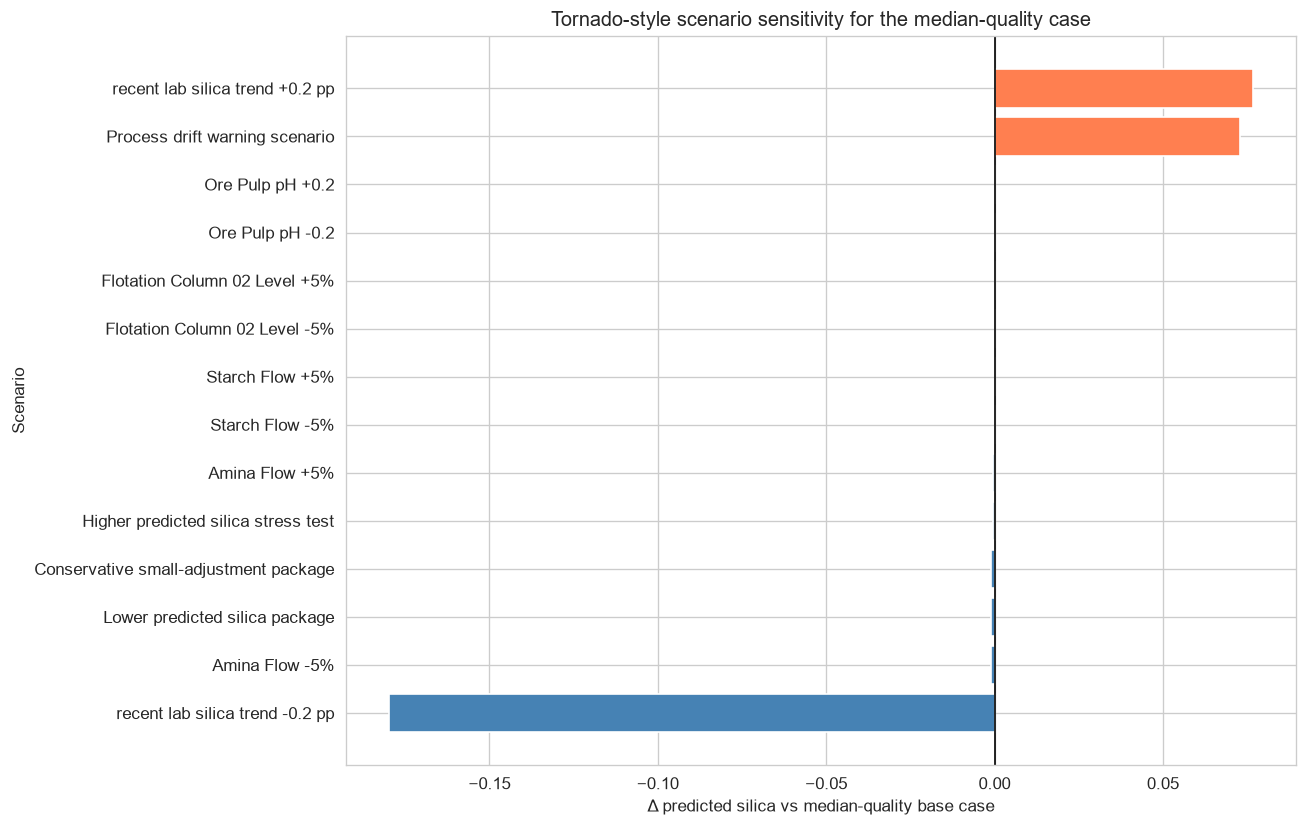

Saved: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\scenario_delta_bar_by_case.png
Saved: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\tornado_sensitivity_median_case.png


In [32]:
scenario_order = (

    scenario_results.groupby('scenario_name')['delta_prediction']

    .mean()

    .sort_values()

    .index.tolist()

)



plot_scenarios = (

    scenario_results.groupby('scenario_name')['delta_prediction']

    .mean()

    .abs()

    .sort_values(ascending=False)

    .head(10)

    .index

)

plot_df = scenario_results[scenario_results['scenario_name'].isin(plot_scenarios)].copy()

plot_df['scenario_name'] = pd.Categorical(plot_df['scenario_name'], categories=[s for s in scenario_order if s in plot_scenarios], ordered=True)



fig, ax = plt.subplots(figsize=(13, 5))

sns.barplot(

    data=plot_df,

    x='scenario_name',

    y='delta_prediction',

    hue='base_case_id',

    ax=ax,

)

ax.axhline(0, color='black', linewidth=1)

ax.set_title('Scenario delta by base case')

ax.set_xlabel('Scenario')

ax.set_ylabel('Δ predicted silica vs base case')

plt.xticks(rotation=35, ha='right')

plt.tight_layout()

scenario_delta_bar_path = FIGURES_PATH / 'scenario_delta_bar_by_case.png'

plt.savefig(scenario_delta_bar_path, dpi=150, bbox_inches='tight')

plt.show()



median_case_plot = scenario_results.loc[

    scenario_results['base_case_id'] == 'median_quality_case'

].copy()

median_case_plot = median_case_plot.sort_values('delta_prediction')

fig, ax = plt.subplots(figsize=(11, 7))

colours = ['steelblue' if value < 0 else 'coral' for value in median_case_plot['delta_prediction']]

ax.barh(median_case_plot['scenario_name'], median_case_plot['delta_prediction'], color=colours, edgecolor='white')

ax.axvline(0, color='black', linewidth=1)

ax.set_title('Tornado-style scenario sensitivity for the median-quality case')

ax.set_xlabel('Δ predicted silica vs median-quality base case')

ax.set_ylabel('Scenario')

plt.tight_layout()

tornado_path = FIGURES_PATH / 'tornado_sensitivity_median_case.png'

plt.savefig(tornado_path, dpi=150, bbox_inches='tight')

plt.show()



print(f'Saved: {scenario_delta_bar_path}')

print(f'Saved: {tornado_path}')


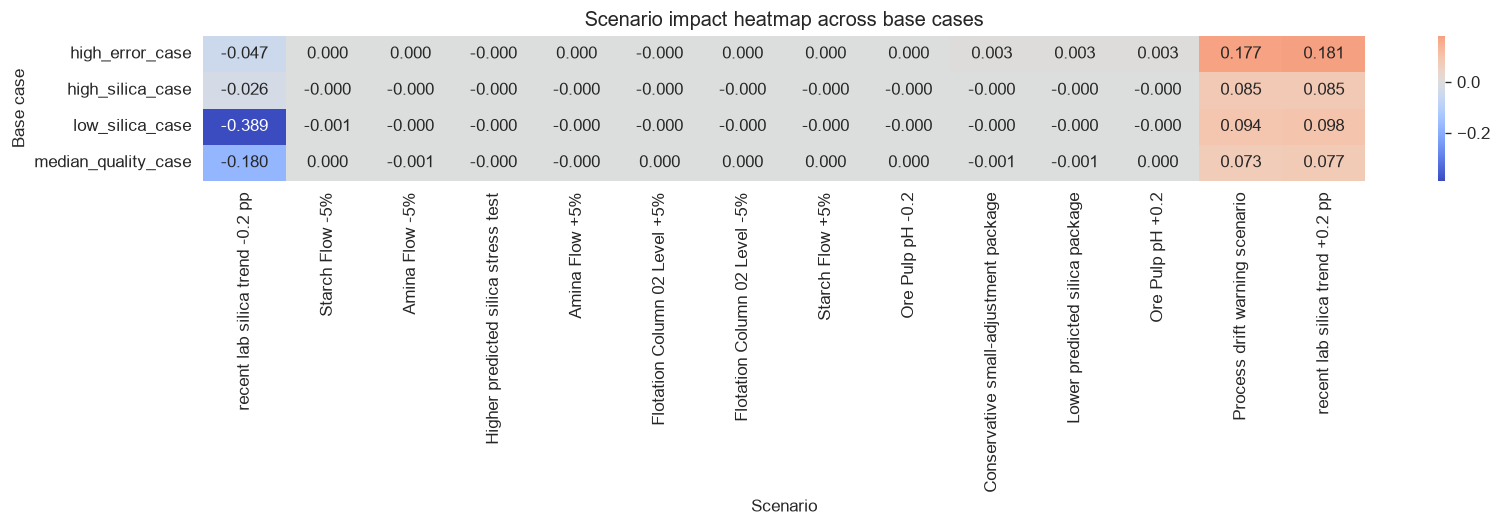

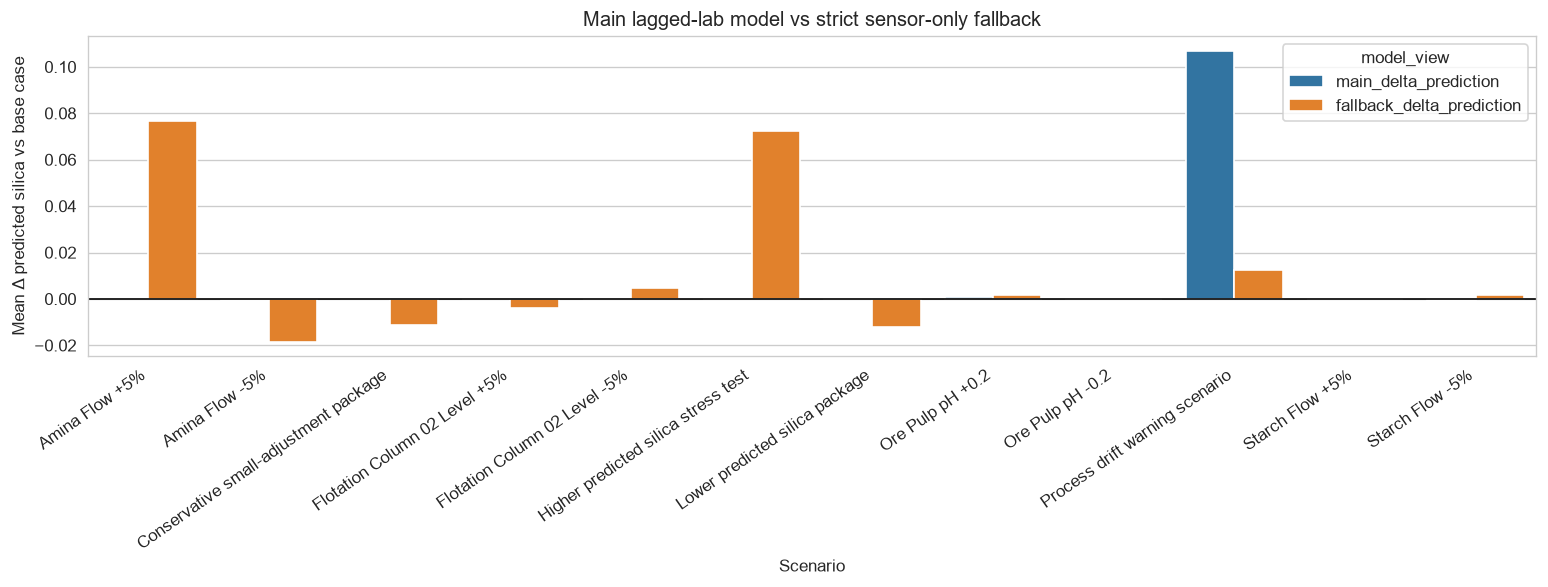

Saved: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\main_vs_fallback_simulation.png
Saved: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\scenario_impact_heatmap.png


In [33]:
heatmap_df = scenario_results.pivot(

    index='base_case_id',

    columns='scenario_name',

    values='delta_prediction',

)

heatmap_df = heatmap_df.loc[:, scenario_order]



fig, ax = plt.subplots(figsize=(14, 4.5))

sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)

ax.set_title('Scenario impact heatmap across base cases')

ax.set_xlabel('Scenario')

ax.set_ylabel('Base case')

plt.tight_layout()

scenario_heatmap_path = FIGURES_PATH / 'scenario_impact_heatmap.png'

plt.savefig(scenario_heatmap_path, dpi=150, bbox_inches='tight')

plt.show()



main_vs_fallback_figure_path = FIGURES_PATH / 'main_vs_fallback_simulation.png'

if not main_vs_fallback_simulation.empty:

    compare_plot_df = (

        main_vs_fallback_simulation.groupby('scenario_name', as_index=False)

        .agg(

            main_delta_prediction=('main_delta_prediction', 'mean'),

            fallback_delta_prediction=('fallback_delta_prediction', 'mean'),

        )

        .melt(id_vars='scenario_name', var_name='model_view', value_name='mean_delta_prediction')

    )

    fig, ax = plt.subplots(figsize=(13, 5))

    sns.barplot(

        data=compare_plot_df,

        x='scenario_name',

        y='mean_delta_prediction',

        hue='model_view',

        ax=ax,

    )

    ax.axhline(0, color='black', linewidth=1)

    ax.set_title('Main lagged-lab model vs strict sensor-only fallback')

    ax.set_xlabel('Scenario')

    ax.set_ylabel('Mean Δ predicted silica vs base case')

    plt.xticks(rotation=35, ha='right')

    plt.tight_layout()

    plt.savefig(main_vs_fallback_figure_path, dpi=150, bbox_inches='tight')

    plt.show()

    print(f'Saved: {main_vs_fallback_figure_path}')

else:

    print('Main-vs-fallback figure skipped because the comparison table is empty.')



print(f'Saved: {scenario_heatmap_path}')


---

## 6. Traceability, Robustness, and Decision-Support Framing



This section saves reproducible artifacts, optionally logs the what-if analysis

to MLflow, and summarises where the scenario analysis looks more robust versus

where it should be treated as low-confidence exploratory support.


In [34]:
artifact_paths = [

    base_cases_path,

    taxonomy_path,

    sensitivity_evidence_path,

    scenario_parameters_path,

    scenario_results_path,

    scenario_ranking_path,

    lab_delay_csv_path,

    lab_delay_r2_path,

    scenario_delta_bar_path,

    tornado_path,

    scenario_heatmap_path,

]

if main_vs_fallback_path is not None:

    artifact_paths.append(main_vs_fallback_path)

if main_vs_fallback_figure_path.exists():

    artifact_paths.append(main_vs_fallback_figure_path)



primary_metadata = model_metadata.get('recommended_model_with_lagged_lab_assumption', {})

mlflow_status = log_to_mlflow(

    model=model,

    model_name=primary_metadata.get('model_name', type(model).__name__),

    train_metrics={},

    val_metrics=primary_metadata.get('validation_metrics', {}),

    cfg=CFG,

    scenario_name='what_if_simulation_analysis',

    test_metrics=primary_metadata.get('test_metrics', {}),

    feature_columns=list(X_test.columns),

    model_path=primary_model_path,

    artifact_paths=artifact_paths,

    extra_params={

        'analysis_name': 'what_if_simulation_analysis',

        'n_base_cases': len(base_case_rows),

        'base_case_ids': list(base_case_rows.keys()),

        'n_scenarios': len(scenario_catalog),

        'lab_delay_primary_scenario': principal_lagged_lab_scenario,

        'strict_sensor_only_available': strict_sensor_only_model is not None,

        'scenario_parameters_path': str(scenario_parameters_path),

    },

    tags={

        'notebook': '04_simulation_what_if',

        'analysis_type': 'what_if_simulation',

        'selection_protocol': model_metadata.get('selection_protocol', 'n/a'),

    },

    run_name='what_if_simulation_analysis',

)



print('MLflow / local traceability status:')

print(mlflow_status)

print('\nArtifacts saved locally:')

for artifact in artifact_paths:

    print(f'- {artifact}')


2026/06/15 18:06:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 18:06:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/15 18:08:41 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\A805B~1.ALV\AppData\Local\Temp\tmpcmr6glzm\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


[train] MLflow run logged for: Random Forest
MLflow / local traceability status:
{'status': 'mlflow_logged', 'experiment_name': 'MINSUR Silica Prediction - Temporal Modeling', 'run_name': 'what_if_simulation_analysis', 'run_id': '80416cfa426544b5ab9a7363ee1e20c0'}

Artifacts saved locally:
- \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\base_cases_summary.csv
- \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\top_shap_feature_taxonomy.csv
- \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\scenario_sensitivity_evidence.csv
- \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\scenario_parameters.json
- \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\scenario_results.csv
- \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\repo

In [37]:
largest_reduction = scenario_summary.sort_values('mean_delta_prediction').iloc[0]

largest_increase = scenario_summary.sort_values('mean_delta_prediction', ascending=False).iloc[0]

robust_scenarios = scenario_summary.loc[

    scenario_summary['consistent_direction_across_cases']

].sort_values(['std_delta_prediction', 'mean_delta_prediction']).head(3)

extrapolation_risks = scenario_summary.loc[

    scenario_summary['extrapolation_cases'] > 0

].sort_values(['extrapolation_cases', 'extrapolation_share'], ascending=False).head(3)



lab_trend_top = scenario_summary.loc[

    scenario_summary['scenario_type'] == 'lab_trend_feature'

] .sort_values('mean_delta_prediction', key=lambda s: s.abs(), ascending=False)



if not main_vs_fallback_simulation.empty:

    agreement_rate = float(main_vs_fallback_simulation['direction_agreement'].mean())

    fallback_less_sensitive_rate = float(main_vs_fallback_simulation['fallback_less_sensitive'].mean())

    disagreement_rate = 1 - agreement_rate

    low_agreement_scenarios = scenario_summary.loc[

        scenario_summary['main_vs_fallback_agreement_rate'].notna()

        & (scenario_summary['main_vs_fallback_agreement_rate'] < 0.5),

        'scenario_name'

    ].tolist()

    fallback_message = (

        f'Across comparable scenarios, direction agreement is {agreement_rate:.1%}; '

        f'the fallback is less sensitive in {fallback_less_sensitive_rate:.1%} of cases; '

        f'direction disagreement appears in {disagreement_rate:.1%} of cases.'

    )

else:

    agreement_rate = np.nan

    low_agreement_scenarios = []

    fallback_message = (

        'The strict sensor-only fallback was not available, so no cross-model scenario comparison was produced.'

    )



print('Executive conclusions — What-if simulation')

print('1. Scenarios with the largest prediction changes:')

print(

    f"   - Largest mean decrease: {largest_reduction['scenario_name']} "

    f"({largest_reduction['mean_delta_prediction']:.4f} predicted silica units on average)."

)

print(

    f"   - Largest mean increase: {largest_increase['scenario_name']} "

    f"({largest_increase['mean_delta_prediction']:.4f} predicted silica units on average)."

)



print('2. Hallazgo implementado — dependencia de tendencia de laboratorio:')

if lab_trend_top.empty:

    print('   - No lab-trend scenarios were available in this run.')

else:

    for _, row in lab_trend_top.head(2).iterrows():

        print(

            f"   - {row['scenario_name']} | mean_delta={row['mean_delta_prediction']:.4f} | "

            f"recommended_use={row['recommended_use']}"

        )

    print('   - Estos escenarios se etiquetan como exploratory_not_operational_recommendation por dependencia de disponibilidad de lags de laboratorio.')



print('3. Hallazgo implementado — cambio de interpretación sin lags de laboratorio:')

print(f'   - {fallback_message}')

if not np.isnan(agreement_rate) and agreement_rate < 0.5:

    print('   - Como el acuerdo direccional global es menor a 50%, los escenarios con bajo acuerdo se tratan como soporte exploratorio y no como recomendación operativa.')

    if low_agreement_scenarios:

        print(f"   - Escenarios con low_cross_model_agreement_exploratory: {', '.join(low_agreement_scenarios)}")



print('4. Scenarios that look more robust across base cases:')

for _, row in robust_scenarios.iterrows():

    print(

        f"   - {row['scenario_name']} | std={row['std_delta_prediction']:.4f} | "

        f"consistent_direction={row['consistent_direction_across_cases']} | "

        f"recommended_use={row['recommended_use']}"

    )



print('5. Scenarios with extrapolation risk:')

if extrapolation_risks.empty:

    print('   - None of the evaluated scenarios left the historical training range.')

else:

    for _, row in extrapolation_risks.iterrows():

        print(

            f"   - {row['scenario_name']} | extrapolation_cases={int(row['extrapolation_cases'])} "

            f"out of {len(base_case_rows)} | recommended_use={row['recommended_use']}"

        )



print('6. What must be validated with plant experts:')

print('   - Whether scenario magnitudes are operationally feasible, economically acceptable, and metallurgically safe.')

print('   - Whether scenarios tagged exploratory_not_operational_recommendation should be used only as monitoring/stress-test references.')



print('7. Why this remains decision-support rather than automatic control:')

print('   - The outputs are learned statistical predictions under historical patterns; they are not causal effect estimates or closed-loop control instructions.')


Executive conclusions — What-if simulation
1. Scenarios with the largest prediction changes:
   - Largest mean decrease: recent lab silica trend -0.2 pp (-0.1604 predicted silica units on average).
   - Largest mean increase: recent lab silica trend +0.2 pp (0.1101 predicted silica units on average).
2. Hallazgo implementado — dependencia de tendencia de laboratorio:
   - recent lab silica trend -0.2 pp | mean_delta=-0.1604 | recommended_use=exploratory_not_operational_recommendation
   - recent lab silica trend +0.2 pp | mean_delta=0.1101 | recommended_use=exploratory_not_operational_recommendation
   - Estos escenarios se etiquetan como exploratory_not_operational_recommendation por dependencia de disponibilidad de lags de laboratorio.
3. Hallazgo implementado — cambio de interpretación sin lags de laboratorio:
   - Across comparable scenarios, direction agreement is 43.8%; the fallback is less sensitive in 35.4% of cases; direction disagreement appears in 56.2% of cases.
   - Como e

---

## Executive conclusions — What-if simulation



The printed conclusions below summarise which scenario families change the

prediction the most, which ones look more stable across base cases, where

extrapolation risk appears, and how the interpretation changes when the strict

sensor-only fallback is used instead of the lagged-lab-availability model.



The notebook now materialises these conclusions into explicit `recommended_use`

labels in saved tables, so scenarios with high dependence on laboratory lags or

low cross-model directional agreement are treated as exploratory support rather

than operational recommendation.



These conclusions are **decision-support outputs only**. They should be reviewed

with plant experts before any operational action.


---

## Summary — Level 4 Checklist



| Item | Status |

|---|---|

| Lab delay availability scenarios evaluated | ✅ |

| Multiple base cases selected from the test set | ✅ |

| Scenario impact quantified across cases | ✅ |

| Range / extrapolation validation added | ✅ |

| Main vs fallback comparison included when available | ✅ |

| Trade-offs and risks discussed through scenario robustness checks | ✅ |

| Outputs saved to `reports/metrics/` and `reports/figures/` | ✅ |

| Explicit non-causal framing maintained | ✅ |
